# Анализ ГТД

## Импорт библиотек

In [1]:
import os.path
import pandas as pd
from numpy import linspace, nan, isnan, inf, linspace, radians, sin, cos, log, mean
import matplotlib.pyplot as plt   
from colorama import Fore

from tools import to_roman, isnum, export2file, correlation, show_correlation, Mx, My, rounding
from thermodynamics import R_gas, Cp

In [2]:
def readDataFrame(file_path, file_extension):
    if file_extension == '.pkl':
        df = pd.read_pickle(file_path)
    elif file_extension == '.csv':
        df = pd.read_csv(file_path)
    elif file_extension == '.xlsx':
        df = pd.read_excel(file_path)
    else:
        df = None
    return df

In [3]:
def polygon(n:int, R: int | float, O: tuple[int | float]) -> tuple[list[float], list[float]]:
    """Генерация координат точек многоугольника"""
    if type(n) is not int: raise TypeError('type(n) is int!')
    a = 360 / n
    x, y = [O[0]], [O[1]]
    for i in range(n-1):
        x.append(Mx(x[i],y[i],O[0],O[1],a))
        y.append(My(x[i],y[i],O[0],O[1],a))
    return (x, y)

In [4]:
def node_sketch(type_fig, *args, **kwargs) -> dict[str: list]:
    """Генерация координат схем узлов ГТД"""
    type_fig = type_fig.strip().lower()
    x0 = kwargs.get('x0', 0)
    y0 = kwargs.get('y0', 0)
    x, y = [], []

    if 'inlet' in type_fig:
        x = [[x0 - 0.4, x0 + 0.4, x0 + 0.4, x0 - 0.4]]
        y = [[y0 + 0.4, y0 + 0.4, y0 - 0.4, y0 - 0.4]]
    elif 'compressor' in type_fig:
        x = [[x0 - 0.4, x0 + 0.4, x0 + 0.4, x0 - 0.4, x0 - 0.4]]
        y = [[y0 + 0.4, y0 + 0.2, y0 - 0.2, y0 - 0.4, y0 + 0.4]]
    elif 'combustionchamber' in type_fig:
        x = [[0.4 * cos(alpha) + x0 for alpha in linspace(0, radians(360), 360)]]
        y = [[0.4 * sin(alpha) + y0 for alpha in linspace(0, radians(360), 360)]]
    elif 'turbine' in type_fig:
        x = [[x0 - 0.4, x0 + 0.4, x0 + 0.4, x0 - 0.4, x0 - 0.4]]
        y = [[y0 + 0.2, y0 + 0.4, y0 - 0.4, y0 - 0.2, y0 + 0.2]]
    elif 'nozzle' in type_fig:
        x = [[x0 - 0.4, x0, x0 + 0.4, x0 + 0.4, x0, x0 - 0.4, x0 - 0.4]]
        y = [[y0 + 0.4, y0 + 0.2, y0 + 0.4, y0 - 0.4, y0 - 0.2, y0 - 0.4, y0 + 0.4]]
    elif 'outlet' in type_fig:
        x = [[x0 + 0.4, x0 - 0.4, x0 - 0.4, x0 + 0.4]]
        y = [[y0 + 0.4, y0 + 0.4, y0 - 0.4, y0 - 0.4]]
    elif 'heatexchanger' in type_fig:
        x = [[x0 - 0.4, x0 + 0.4, x0 + 0.4, x0 - 0.4, x0 - 0.4], [x0 - 0.2, x0 - 0.1, x0, x0 + 0.1, x0 + 0.2]]
        y = [[y0 + 0.4, y0 + 0.4, y0 - 0.4, y0 - 0.4, y0 + 0.4], [y0 + 0.1, y0 - 0.1, y0 + 0.1, y0 - 0.1, y0 + 0.1]]
    elif 'load' in type_fig:
        x = [[x0 - 0.4, x0, x0 + 0.4, x0 - 0.4]]
        y = [[y0 - 0.4, y0 + 0.4, y0 - 0.4, y0 - 0.4]]
    return {'x': x, 'y': y}

In [5]:
def show_analysis(df, keys_var, keys, savefig=False, **kwargs):
    res = dict()
    plt.figure(figsize=(9, 9))
    plt.suptitle('GTE analysis | анализ ГТД', fontsize=16, fontweight='bold')

    D = len(keys)  # мерность пространства
    if 1 == D:
        dct = df.to_dict('list')
        title = f"{keys['z']}"
        plt.title(title, fontsize=14)
        plt.grid(True)
        plt.hist(dct[keys['z']], label=f"{rounding(mean(dct[keys['z']]), 4)}")
        plt.xlabel(keys['z'], fontsize=14)
        plt.ylabel('density []', fontsize=14)
    elif 2 == D:
        dct = df.sort_values(by=[keys['x']], ascending=True).to_dict('list')
        for i in range(len(df.index)):
            key = ''
            for k in dct:
                if k not in keys.values() and k in keys_var: key += k + ' = ' + str(rounding(dct[k][i], 2)) + '; '
            if key in res:
                res[key][0].append(dct[keys['x']][i]), res[key][1].append(dct[keys['z']][i])
            else:
                res[key] = [[dct[keys['x']][i]], [dct[keys['z']][i]]]

        title = f"{keys['z']}({keys['x']})"
        plt.title(title, fontsize=14)
        plt.grid(True)
        for label, xyz in res.items(): plt.plot(*xyz,
                                                linestyle='-', linewidth=1.5,
                                                marker='o', markersize=3,
                                                label=label)
        plt.xlabel(keys['x'], fontsize=14)
        plt.ylabel(keys['z'], fontsize=14)
    elif 3 == D:
        dct = df.sort_values(by=[keys['x'], keys['y']], ascending=True).to_dict('list')
        for i in range(len(df.index)):
            key = ''
            for k in dct:
                if k not in keys.values(): key += k + ' = ' + str(rounding(dct[k][i], 2)) + '; '
            if key in res:
                res[key][0].append(dct[keys['x']][i])
                res[key][1].append(dct[keys['y']][i])
                res[key][2].append(dct[keys['z']][i])
            else:
                res[key] = [[dct[keys['x']][i]], [dct[keys['y']][i]], [dct[keys['z']][i]]]

        title = f"{keys['z']}({keys['x']}, {keys['y']})"
        plt.title(title, fontsize=14)
        for label, xyz in res.items(): plt.contourf(*xyz, levels=30, cmap='plasma',
                                                    label=label)  # cmap='vinidis'
        plt.colobar(label=keys['z'])
    else:
        raise '4D dimention!'

    # for k, v in res.items(): print(k, v)

    plt.xticks(fontsize=12), plt.yticks(fontsize=12)
    # plt.legend(fontsize=12, loc='best')
    if savefig: export2file(plt, file_path='exports/analysis',
                            file_name='Analysis', file_type='png', show_time=True, **kwargs)
    plt.show()

In [6]:
def draw_longitudinal_section_parameters(self):
    """График распределения термодинамических параметров по продольному сечению ГТД"""
    fg = plt.figure(figsize=(13, 6))  # размер в дюймах
    fg.suptitle('Thermodynamic parameters | Термодинамические параметры', fontsize=16, fontweight='bold')
    gs = fg.add_gridspec(1, len(self.scheme))  # строки, столбцы

    step_node = 8
    step = 2

    for contour in self.scheme:
        x = [1]
        TT, PP, ρρ, g = [], [], [], []
        for node in self.scheme[contour]:
            x.append(x[-1] + step_node)
            TT.append(node.TT1)
            PP.append(node.PP1)
            ρρ.append(node.ρρ1)
            g.append(node.g1)
            x.append(x[-1] + step)
            TT.append(node.TT3)
            PP.append(node.PP3)
            ρρ.append(node.ρρ3)
            g.append(node.g3)
        x.pop(-1)

        ax = fg.add_subplot(gs[0, contour - 1])  # позиция графика
        plt.title('contour ' + to_roman(contour) + ' | ' + 'контур ' + to_roman(contour), fontsize=14)
        plt.grid(True)
        plt.ylim([-0.1, 1.1])
        ax.set_xticks(range(0, len(x) * 10, 10))
        ax.set_yticks(linspace(-0.1, 1.1, 13))
        plt.xlabel('nodes | узлы', fontsize=14)

        for i, node in enumerate(self.scheme[contour]):
            plt.text(x[2 * i], 0, type(node).__name__ + '1', fontsize=12, rotation=90)
            plt.text((x[2 * i] + x[2 * i + 1]) / 2, 0, type(node).__name__, fontsize=12, rotation=90)
            plt.text(x[2 * i + 1], 0, type(node).__name__ + '3', fontsize=12, rotation=90)

        plt.plot(list(x[i] for i, _ in enumerate(x)), list(TT[i] / max(TT) for i, _ in enumerate(x)),
                 color='red', ls='-', linewidth=2, marker='o', label='T*')
        plt.plot(list(x[i] for i, _ in enumerate(x)), list(PP[i] / max(PP) for i, _ in enumerate(x)),
                 color='blue', ls='-', linewidth=2, marker='o', label='P*')
        plt.plot(list(x[i] for i, _ in enumerate(x)), list(ρρ[i] / max(ρρ) for i, _ in enumerate(x)),
                 color='green', ls='-', linewidth=2, marker='o', label='ρ*')
        plt.plot(list(x[i] for i, _ in enumerate(x)), list(g[i] / max(g) for i, _ in enumerate(x)),
                 color='brown', ls='-', linewidth=2, marker='o', label='G')
    fg.legend(loc='outside left center', fontsize=12)
    export2file(plt, file_name='GTE_longitudinal_section_parameters', file_type='png', show_time=True)
    plt.show()

In [7]:
def delta_entrophy(Cp2=nan, T1=nan, T3=nan, R2=nan, P1=nan, P3=nan,
                   a_ox1=nan, a_ox2=nan, a_ox3=nan, substance='', fuel='') -> float:
    """Изменение энтропии [Дж/кг]"""
    if Cp2 is nan: Cp2 = Cp(substance, T=0.5 * (T1 + T3))  # TODO среднее значение через интеграл
    if R2 is nan:
        if a_ox2 is nan:
            R2 = R_gas(substance, a_ox=0.5 * (a_ox1 + a_ox3), fuel=fuel)  # TODO среднее значение через интеграл
        else:
            R2 = R_gas(substance, a_ox=a_ox2, fuel=fuel)
    return Cp2 * log(T3 / T1) - R2 * log(P3 / P1)

In [8]:
def draw_cycle(scheme: dict, type_cycle: str) -> None:
    """График цикла ГТД"""
    fg = plt.figure(figsize=(13, 6))  # размер в дюймах
    fg.suptitle('CYCLE GTE | ЦИКЛ ГТД', fontsize=14, fontweight='bold')
    gs = fg.add_gridspec(1, len(scheme))  # строки, столбцы
    if type_cycle.upper() in ('TS', 'T(S)', 'T_S', 'ST', 'S(T)', 'S_T'):
        for contour in scheme:
            # начало отсчета
            S = [0]  # [Дж/кг]
            T = [288.15]  # [К] МСА
            P = [101325]  # [Па] МСА
            for node in scheme[contour]:
                # перед
                S.append(S[len(S) - 1] + delta_entrophy(Cp2=node.Cp1, T1=T[len(T) - 1], T3=node.TT1,
                                                        R2=node.R_gas1, P1=P[len(P) - 1], P3=node.PP1))
                T.append(node.TT1)
                P.append(node.PP1)
                # после
                S.append(S[len(S) - 1] + delta_entrophy(Cp2=node.Cp3, T1=T[len(T) - 1], T3=node.TT3,
                                                        R2=node.R_gas3, P1=P[len(P) - 1], P3=node.PP3))
                T.append(node.TT3)
                P.append(node.PP3)

            del S[0], T[0], P[0]  # удаление начала отсчета

            if len(S) >= 3:  # замкнутость цикла
                S.append(S[0])
                T.append(T[0])
                P.append(P[0])

            # TODO сделать тут промежуточные значения между характерными точками в количестве dis штук

            print(Fore.MAGENTA + 'contour ', to_roman(contour), '|', Fore.MAGENTA + 'контур ', to_roman(contour))
            for i in range(len(S)): print('T =', round(T[i], 3), '[К]', ';', 'S =', round(S[i], 3), '[Дж/К]')

            fg.add_subplot(gs[0, contour - 1])  # позиция графика
            plt.grid(True)
            plt.xlabel('S [Дж/кг]', fontsize=12)
            plt.ylabel('T [К]', fontsize=12)
            plt.title('contour ' + to_roman(contour) + ' | ' + 'контур ' + to_roman(contour), fontsize=12)
            plt.plot(S, T, color=(0, 0, 0), ls='-', linewidth=2, marker='o')
            i = 0
            for node in scheme[contour]:
                plt.text(S[i], T[i], type(node).__name__ + '1', color=(0, 1, 1), fontsize=12)
                i += 1
                plt.text(S[i], T[i], type(node).__name__ + '3', color=(0, 1, 1), fontsize=12)
                i += 1

        export2file(plt, file_name='GTE_cycle_T(S)', file_type='png', show_time=True)
        plt.show()
    else:
        print(Fore.RED + 'No find such typy of cycle!')

## Подключение файлов

In [9]:
input_file_path = 'exports/CFM-56 input.xlsx'
output_file_path = 'exports/CFM-56.xlsx'

In [10]:
def existfile(file):
    if os.path.isfile(file): 
        file_name, file_extension = os.path.splitext(os.path.basename(file))[0], os.path.splitext(file)[1] 
        if file_extension not in ('.pkl', '.csv', '.xlsx'):
            print(f'{file} неизвестное расширение!')
        else:
            return {'name': file_name, 'extension': file_extension}
    else:
        print(f'{file} не существет!')
        exit()

In [11]:
input_file_name, input_file_extension = existfile(input_file_path)['name'], existfile(input_file_path)['extension']
output_file_name, output_file_extension = existfile(output_file_path)['name'], existfile(output_file_path)['extension']
print([input_file_name, input_file_extension])
print([output_file_name, output_file_extension])

exports/CFM-56 input.xlsx не существет!


TypeError: 'NoneType' object is not subscriptable

: 

## Чтение данных

In [ ]:
input_df = readDataFrame(input_file_path, input_file_extension)
output_df = readDataFrame(output_file_path, output_file_extension)
export2file(output_df, file_place='exports/', file_name='resave', file_type='xlsx', sheet_name='Cycle', show_time=True)

resave 2023-10-07 13-47-12.xlsx file has created!
Elapsed time: 0.5744 seconds


In [ ]:
input_df.T

,0
contourI,Inlet_0+Compressor_1+Compressor_2+CombustionCh...
contourII,Inlet_5+Compressor_6+Nozzle_9
loads,NaN
mI [],"[1, 1, 1, 1, 1]"
mII [],"[4, 5, 6, 7, 8]"
H [м],[11000]
M [],[0.8]
R [кН],[80.0]
resource [ч],[5000.0]
oxidizer,['AIR']


In [ ]:
output_df

,contourI,contourII,loads,mI [],mII [],warnings,H [м],M [],R [кН],resource [ч],...,Nozzle_9 k3,Nozzle_9 a_ox1,Nozzle_9 a_ox3,Nozzle_9 R_,Nozzle_9 ππ_max,Nozzle_9 ππ,Nozzle_9 ηη,Nozzle_9 ηn,Nozzle_9 v_,Nozzle_9 g_leak
0,Inlet_0+Compressor_1+Compressor_2+CombustionCh...,Inlet_5+Compressor_6+Nozzle_9,NaN,1,4,Не достигнута заданная тяга!,11000,0.8,80,5000,...,1.401007,inf,inf,NaN,1.893537,0.670174,0.96,0.962124,0.98,0.001
1,Inlet_0+Compressor_1+Compressor_2+CombustionCh...,Inlet_5+Compressor_6+Nozzle_9,NaN,1,5,Не достигнута заданная тяга!; T*3 < 0 [К]! Не ...,11000,0.8,80,5000,...,1.401007,inf,inf,NaN,1.893537,0.670174,0.96,0.962124,0.98,0.001
2,Inlet_0+Compressor_1+Compressor_2+CombustionCh...,Inlet_5+Compressor_6+Nozzle_9,NaN,1,6,Не достигнута заданная тяга!; T*3 < 0 [К]! Не ...,11000,0.8,80,5000,...,1.401007,inf,inf,NaN,1.893537,0.670174,0.96,0.962124,0.98,0.001
3,Inlet_0+Compressor_1+Compressor_2+CombustionCh...,Inlet_5+Compressor_6+Nozzle_9,NaN,1,7,Не достигнута заданная тяга!; T*3 < 0 [К]! Не ...,11000,0.8,80,5000,...,1.401007,inf,inf,NaN,1.893537,0.670174,0.96,0.962124,0.98,0.001
4,Inlet_0+Compressor_1+Compressor_2+CombustionCh...,Inlet_5+Compressor_6+Nozzle_9,NaN,1,8,Не достигнута заданная тяга!; T*3 < 0 [К]! Не ...,11000,0.8,80,5000,...,1.401007,inf,inf,NaN,1.893537,0.670174,0.96,0.962124,0.98,0.001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,Inlet_0+Compressor_1+Compressor_2+CombustionCh...,Inlet_5+Compressor_6+Nozzle_9,NaN,1,4,Не достигнута заданная тяга!; T*3 < 0 [К]! Не ...,11000,0.8,80,5000,...,1.396055,inf,inf,NaN,1.890548,0.670174,0.96,0.962106,0.98,0.001
121,Inlet_0+Compressor_1+Compressor_2+CombustionCh...,Inlet_5+Compressor_6+Nozzle_9,NaN,1,5,Не достигнута заданная тяга!; T*3 < 0 [К]! Не ...,11000,0.8,80,5000,...,1.396055,inf,inf,NaN,1.890548,0.670174,0.96,0.962106,0.98,0.001
122,Inlet_0+Compressor_1+Compressor_2+CombustionCh...,Inlet_5+Compressor_6+Nozzle_9,NaN,1,6,Не достигнута заданная тяга!; T*3 < 0 [К]! Не ...,11000,0.8,80,5000,...,1.396055,inf,inf,NaN,1.890548,0.670174,0.96,0.962106,0.98,0.001
123,Inlet_0+Compressor_1+Compressor_2+CombustionCh...,Inlet_5+Compressor_6+Nozzle_9,NaN,1,7,Не достигнута заданная тяга!; T*3 < 0 [К]! Не ...,11000,0.8,80,5000,...,1.396055,inf,inf,NaN,1.890548,0.670174,0.96,0.962106,0.98,0.001


In [ ]:
output_df[['warnings', 'H [м]', 'M []', 'GI [кг/с]', 'G fuel [г/с]', 'g fuel [%]']]

,warnings,H [м],M [],GI [кг/с],G fuel [г/с],g fuel [%]
0,Не достигнута заданная тяга!,11000,0.8,0.0,0.0,3.059272
1,Не достигнута заданная тяга!; T*3 < 0 [К]! Не ...,11000,0.8,NaN,NaN,3.059272
2,Не достигнута заданная тяга!; T*3 < 0 [К]! Не ...,11000,0.8,0.0,0.0,3.059272
3,Не достигнута заданная тяга!; T*3 < 0 [К]! Не ...,11000,0.8,NaN,NaN,3.059272
4,Не достигнута заданная тяга!; T*3 < 0 [К]! Не ...,11000,0.8,0.0,0.0,3.059272
...,...,...,...,...,...,...
120,Не достигнута заданная тяга!; T*3 < 0 [К]! Не ...,11000,0.8,0.0,0.0,3.738479
121,Не достигнута заданная тяга!; T*3 < 0 [К]! Не ...,11000,0.8,NaN,NaN,3.738479
122,Не достигнута заданная тяга!; T*3 < 0 [К]! Не ...,11000,0.8,0.0,0.0,3.738479
123,Не достигнута заданная тяга!; T*3 < 0 [К]! Не ...,11000,0.8,NaN,NaN,3.738479


## Обработка данных

Информация о БД

In [ ]:
output_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Columns: 342 entries, contourI to Nozzle_9 g_leak
dtypes: float64(307), int64(26), object(9)
memory usage: 445.8 KB


In [ ]:
#output_df.dropna(axis=1, inplace=True)

In [ ]:
input_dct = input_df.to_dict('list')
output_dct = output_df.to_dict('list')

Разорхивирование списка варьирований из списка

In [ ]:
for key, value in input_dct.items(): input_dct[key] = input_dct[key][0]

In [ ]:
for key, value in input_dct.items():
    if type(value) is str:
        input_dct[key] = input_dct[key].replace('[', '')
        input_dct[key] = input_dct[key].replace(']', '')
        input_dct[key] = input_dct[key].split(', ')
input_dct

{'contourI': ['Inlet_0+Compressor_1+Compressor_2+CombustionChamber_3+Turbine_4+Turbine_7+Nozzle_8'],
 'contourII': ['Inlet_5+Compressor_6+Nozzle_9'],
 'loads': nan,
 'mI []': ['1', '1', '1', '1', '1'],
 'mII []': ['4', '5', '6', '7', '8'],
 'H [м]': ['11000'],
 'M []': ['0.8'],
 'R [кН]': ['80.0'],
 'resource [ч]': ['5000.0'],
 'oxidizer': ["'AIR'"],
 'fuel': ["'KEROSENE'"],
 'Inlet_0 σ': ['0.98'],
 'Inlet_0 g_leak': ['0.005'],
 'Compressor_1 ππ': ['1.2'],
 'Compressor_1 ηη': ['0.88'],
 'Compressor_1 g_leak': ['0.05'],
 'Compressor_2 ππ': ['12'],
 'Compressor_2 ηη': ['0.87'],
 'Compressor_2 g_leak': ['0.05'],
 'CombustionChamber_3 TT3': ['1600.0', '1650.0', '1700.0', '1750.0', '1800.0'],
 'CombustionChamber_3 T_fuel': ['313.15'],
 'CombustionChamber_3 T_lim': ['1800'],
 'CombustionChamber_3 η_burn': ['0.99'],
 'CombustionChamber_3 σ': ['0.94'],
 'CombustionChamber_3 g_leak': ['0'],
 'Turbine_4 shafts': ['<compressor.Compressor object at 0x0000020BC4C35590>'],
 'Turbine_4 coolers': ['']

Вычленение ключей варьируемых параметров

In [ ]:
keys_var = []
for key, value in input_dct.items():
    if (type(value) is str or type(value) is list) and len(value) > 1 and all(isnum(el) for el in value): 
        keys_var.append(key)
keys_var

['mI []', 'mII []', 'CombustionChamber_3 TT3', 'Compressor_6 ππ']

In [ ]:
output_dct

{'contourI': ['Inlet_0+Compressor_1+Compressor_2+CombustionChamber_3+Turbine_4+Turbine_7+Nozzle_8',
  'Inlet_0+Compressor_1+Compressor_2+CombustionChamber_3+Turbine_4+Turbine_7+Nozzle_8',
  'Inlet_0+Compressor_1+Compressor_2+CombustionChamber_3+Turbine_4+Turbine_7+Nozzle_8',
  'Inlet_0+Compressor_1+Compressor_2+CombustionChamber_3+Turbine_4+Turbine_7+Nozzle_8',
  'Inlet_0+Compressor_1+Compressor_2+CombustionChamber_3+Turbine_4+Turbine_7+Nozzle_8',
  'Inlet_0+Compressor_1+Compressor_2+CombustionChamber_3+Turbine_4+Turbine_7+Nozzle_8',
  'Inlet_0+Compressor_1+Compressor_2+CombustionChamber_3+Turbine_4+Turbine_7+Nozzle_8',
  'Inlet_0+Compressor_1+Compressor_2+CombustionChamber_3+Turbine_4+Turbine_7+Nozzle_8',
  'Inlet_0+Compressor_1+Compressor_2+CombustionChamber_3+Turbine_4+Turbine_7+Nozzle_8',
  'Inlet_0+Compressor_1+Compressor_2+CombustionChamber_3+Turbine_4+Turbine_7+Nozzle_8',
  'Inlet_0+Compressor_1+Compressor_2+CombustionChamber_3+Turbine_4+Turbine_7+Nozzle_8',
  'Inlet_0+Compresso

Задание БД

In [ ]:
numeric_output_df = output_df.select_dtypes(['number'])#.dropna(axis=0, inplace=True)

## Анализ

scheme 2023-10-07 13-47-13.png file has created!
Elapsed time: 0.3114 seconds


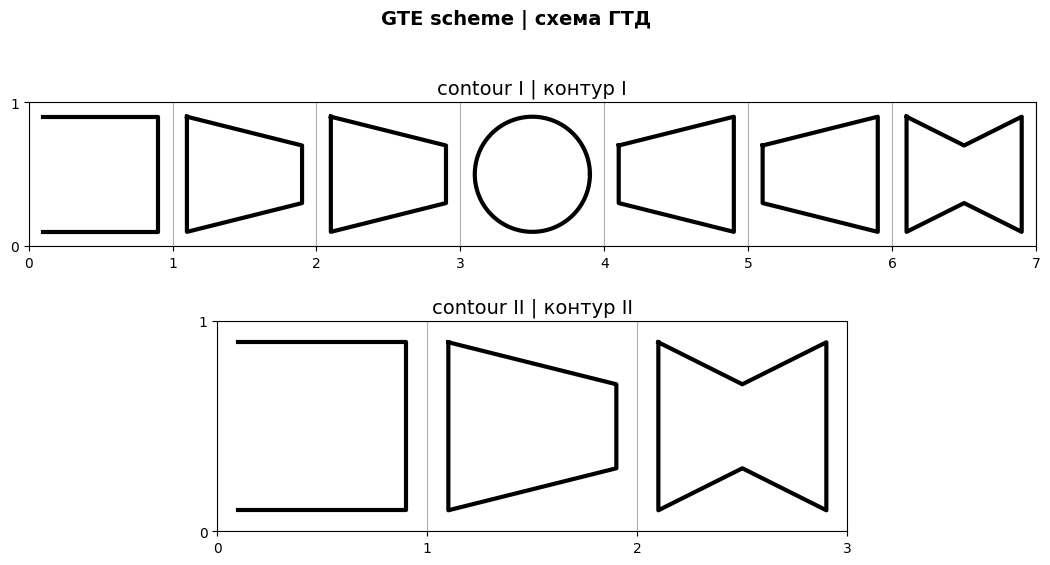

In [ ]:
scheme = dict()
c = 0
for key in input_dct:
    if 'contour' in key: 
        c+=1
        scheme[c] = input_dct[key][0].split('+') 
del c

fg = plt.figure(figsize=(13, 6))  # размер в дюймах
fg.suptitle('GTE scheme | схема ГТД', fontsize=14, fontweight='bold')
gs = fg.add_gridspec(len(scheme), 1)  # строки, столбцы

for contour in scheme:
    fg.add_subplot(gs[contour - 1, 0])
    plt.grid(True)
    plt.axis('square')
    plt.title('contour ' + to_roman(contour) + ' | ' + 'контур ' + to_roman(contour), fontsize=14)
    plt.xlim(0, len(scheme[contour]))
    plt.ylim(0, 1)
    plt.xticks(linspace(0, len(scheme[contour]), len(scheme[contour]) + 1))
    plt.yticks(linspace(0, 1, 1 + 1))

    x0, y0 = 0.5, 0.5

    for node in scheme[contour]:
        xy = node_sketch(node, x0=x0, y0=y0)
        for i in range(len(xy['x'])): plt.plot(xy['x'][i],xy['y'][i], color='black', linewidth=3)
        x0 += 1
export2file(plt, file_place='exports/analysis', file_name='scheme', show_time=True, file_type='png')
plt.show()

Ключи парамтеров

In [ ]:
list(numeric_output_df.columns)

['loads',
 'mI []',
 'mII []',
 'H [м]',
 'M []',
 'R [кН]',
 'resource [ч]',
 'R_ [м/с]',
 'g fuel [%]',
 'GI [кг/с]',
 'GII [кг/с]',
 'G fuel [г/с]',
 'G fuel/N [г/Вт/ч]',
 'G fuel/R [г/Н/ч]',
 'Cx []',
 'Inlet_0 name',
 'Inlet_0 TT1',
 'Inlet_0 TT3',
 'Inlet_0 PP1',
 'Inlet_0 PP3',
 'Inlet_0 ρρ1',
 'Inlet_0 ρρ3',
 'Inlet_0 T1',
 'Inlet_0 T3',
 'Inlet_0 P1',
 'Inlet_0 P3',
 'Inlet_0 ρ1',
 'Inlet_0 ρ3',
 'Inlet_0 c1',
 'Inlet_0 c3',
 'Inlet_0 g1',
 'Inlet_0 g3',
 'Inlet_0 Cp1',
 'Inlet_0 Cp3',
 'Inlet_0 R_gas1',
 'Inlet_0 R_gas3',
 'Inlet_0 k1',
 'Inlet_0 k3',
 'Inlet_0 a_ox1',
 'Inlet_0 a_ox3',
 'Inlet_0 Mc1',
 'Inlet_0 Mc3',
 'Inlet_0 σ',
 'Inlet_0 g_leak',
 'Compressor_1 name',
 'Compressor_1 TT1',
 'Compressor_1 TT3',
 'Compressor_1 PP1',
 'Compressor_1 PP3',
 'Compressor_1 ρρ1',
 'Compressor_1 ρρ3',
 'Compressor_1 T1',
 'Compressor_1 T3',
 'Compressor_1 P1',
 'Compressor_1 P3',
 'Compressor_1 ρ1',
 'Compressor_1 ρ3',
 'Compressor_1 c1',
 'Compressor_1 c3',
 'Compressor_1 g1',
 'C

Ключи варьируемых параметров

In [ ]:
keys_var

['mI []', 'mII []', 'CombustionChamber_3 TT3', 'Compressor_6 ππ']

Analysis 2023-10-07 13-48-56.png file has created!
Elapsed time: 0.2811 seconds


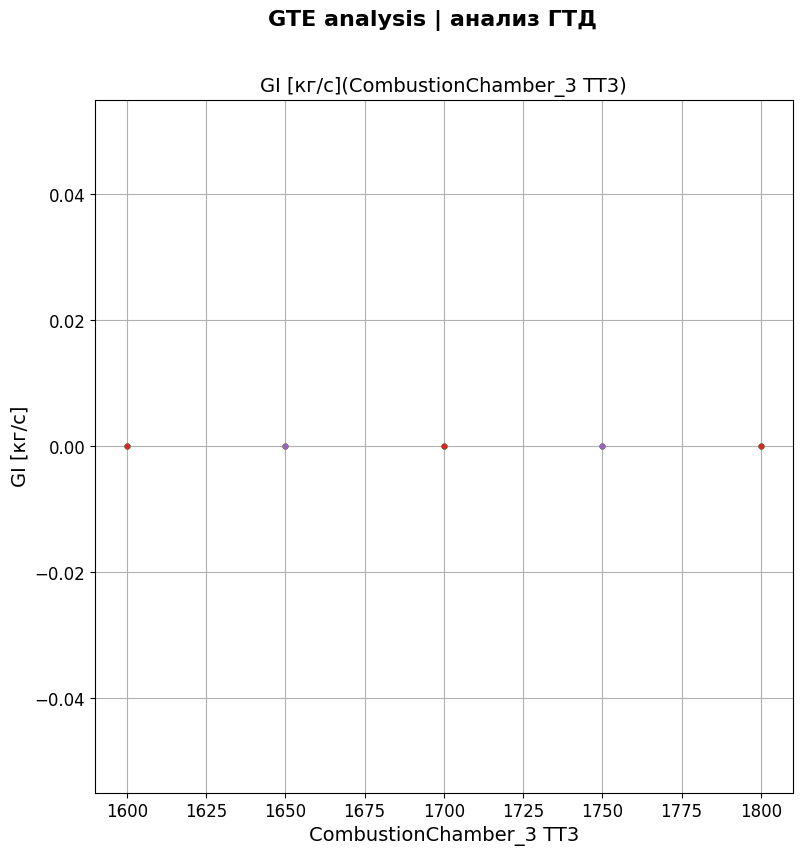

In [ ]:
show_analysis(numeric_output_df, keys_var, {'z': 'GI [кг/с]', 'x': 'CombustionChamber_3 TT3'}, 
     savefig=True, dpi=300)

In [ ]:
cor = correlation(numeric_output_df, method='pearson', only_nums=True)
cor

,mII [],g fuel [%],CombustionChamber_3 TT3,CombustionChamber_3 ρρ3,CombustionChamber_3 g3,CombustionChamber_3 Cp3,CombustionChamber_3 R_gas3,CombustionChamber_3 k3,CombustionChamber_3 a_ox3,CombustionChamber_3 g_fuel,...,Nozzle_9 PP1,Nozzle_9 PP3,Nozzle_9 ρρ1,Nozzle_9 ρρ3,Nozzle_9 Cp1,Nozzle_9 Cp3,Nozzle_9 k1,Nozzle_9 k3,Nozzle_9 ππ_max,Nozzle_9 ηn
mII [],1.000000,-0.016542,-0.016393,0.016883,-0.016542,-0.016717,-0.016542,0.016857,0.017372,-0.016542,...,-0.016393,-0.016393,-0.016841,-0.016841,-0.016850,-0.016850,0.016901,0.016901,0.016901,0.016885
g fuel [%],-0.016542,1.000000,0.999954,-0.999675,1.000000,0.999916,1.000000,-0.999736,-0.998227,1.000000,...,-0.016542,-0.016542,-0.016993,-0.016993,-0.017003,-0.017003,0.017055,0.017055,0.017054,0.017038
CombustionChamber_3 TT3,-0.016393,0.999954,1.000000,-0.999390,0.999954,0.999748,0.999954,-0.999473,-0.997614,0.999954,...,-0.016393,-0.016393,-0.016841,-0.016841,-0.016850,-0.016850,0.016901,0.016901,0.016901,0.016885
CombustionChamber_3 ρρ3,0.016883,-0.999675,-0.999390,1.000000,-0.999675,-0.999922,-0.999675,0.999996,0.999413,-0.999675,...,0.016883,0.016883,0.017343,0.017343,0.017353,0.017353,-0.017406,-0.017406,-0.017406,-0.017390
CombustionChamber_3 g3,-0.016542,1.000000,0.999954,-0.999675,1.000000,0.999916,1.000000,-0.999736,-0.998227,1.000000,...,-0.016542,-0.016542,-0.016993,-0.016993,-0.017003,-0.017003,0.017055,0.017055,0.017054,0.017038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Nozzle_9 Cp3,-0.016850,-0.017003,-0.016850,0.017353,-0.017003,-0.017183,-0.017003,0.017327,0.017856,-0.017003,...,0.999493,0.999493,1.000000,1.000000,1.000000,1.000000,-0.999993,-0.999993,-0.999993,-0.999997
Nozzle_9 k1,0.016901,0.017055,0.016901,-0.017406,0.017055,0.017235,0.017055,-0.017380,-0.017911,0.017055,...,-0.999369,-0.999369,-0.999990,-0.999990,-0.999993,-0.999993,1.000000,1.000000,1.000000,0.999999
Nozzle_9 k3,0.016901,0.017055,0.016901,-0.017406,0.017055,0.017235,0.017055,-0.017380,-0.017911,0.017055,...,-0.999369,-0.999369,-0.999990,-0.999990,-0.999993,-0.999993,1.000000,1.000000,1.000000,0.999999
Nozzle_9 ππ_max,0.016901,0.017054,0.016901,-0.017406,0.017054,0.017235,0.017054,-0.017379,-0.017910,0.017054,...,-0.999370,-0.999370,-0.999990,-0.999990,-0.999993,-0.999993,1.000000,1.000000,1.000000,0.999999


In [ ]:
show_correlation(numeric_output_df, only_nums=True, show_num = True, units='', rnd=2, savefig=True, dpi=100)